In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind
import numpy as np
from statsmodels.stats.multitest import multipletests

In [2]:
SAM_number = 10.5
FDA_number = 3.108

In [4]:
colors_temp = {
    62: "#DF9966",
    57: "#FFC49B",
    52: "#FFEFD3",
    47: "#ADB6C4",
    42: "#3B6F8D",
    37: "#001B2E",
}

In [62]:
tempcurve = pd.read_csv("data/FlA_TempCurve.csv", sep=";")
tempcurve = tempcurve.drop(tempcurve.index[tempcurve["Plate"]!="ZP_TempCurve"])
tempcurve = tempcurve.drop(tempcurve.index[tempcurve["Protein"]=="Ctrl"])
tempcurve = tempcurve.drop(tempcurve.index[tempcurve["Protein"]=="Quad"])

tempcurve['FDA_conc'] = FDA_number*(tempcurve['FDA Area'])
tempcurve['SAM_conc'] = SAM_number*(tempcurve['SAM DG Area'])
tempcurve["%SAM converted"] = tempcurve['FDA_conc'] / (tempcurve['FDA_conc'] + tempcurve['SAM_conc']) * 100



temp_reference = tempcurve[tempcurve["Protein"] == "WT"]
# Merge the reference values back into the original DataFrame based on the same condition
tempcurve = tempcurve.merge(
    temp_reference[["Plate", "Timepoint", "SAM Conc.", "Temp.", "Replicate", "%SAM converted"]],
    on=["Plate", "Timepoint", "SAM Conc.", "Temp.", "Replicate"],
    suffixes=("", "_ref"),
    how="left"
)

# # Calculate Relative_Activity
# tempcurve["Relative_Activity"] = tempcurve["%SAM converted"] / tempcurve["%SAM converted_ref"]

# # Drop the intermediate reference column 
# tempcurve.drop(columns=["%SAM converted_ref"], inplace=True)

for temp in pd.unique(tempcurve["Temp."]):
    temp_subset = tempcurve[tempcurve["Temp."] == temp]
    ref = temp_subset[temp_subset["Protein"] == "WT"]
    wt_conv = ref["%SAM converted"].values
    wt_mean = np.mean(wt_conv)
    tempcurve.loc[tempcurve["Temp."] == temp, 'Relative_Activity'] = tempcurve.loc[tempcurve["Temp."] == temp, '%SAM converted'] / wt_mean
# ref = tempcurve[tempcurve["Protein"] == "WT"]
# wt_conv = ref["%SAM_converted"].values
# wt_mean = np.mean(wt_conv)

# tempcurve['Relative_Activity'] = tempcurve['%SAM_converted'] / wt_mean


In [63]:
tempcurve_conv = pd.melt(tempcurve, id_vars=["Protein", "Temp."], value_vars=["%SAM converted"])


tempcurve_rel = tempcurve.drop(tempcurve.index[tempcurve["Protein"] == "WT"].tolist())
tempcurve_rel = pd.melt(tempcurve_rel, id_vars=["Protein", "Temp."], value_vars=["Relative_Activity"])

# for mut in ["WT","H32L","H191E","G37D","S166A"]:
#     prev_conv = best_mutant_conv[mut]
#     i = tempcurve_conv.shape[0]
#     for val in prev_conv:
#         tempcurve_conv.loc[i] = [mut, 37, '%SAM converted', val]
#         i += 1
#     if mut != "WT":
#         prev_rel = best_mutant_rel[mut]
#         i = tempcurve_rel.shape[0]
#         for val in prev_rel:
#             tempcurve_rel.loc[i] = [mut, 37, 'Relative_Activity', val]
#             i += 1
tempcurve_conv = tempcurve_conv.groupby(by=["Protein", "Temp."])["value"].agg(["mean", "std"]).reset_index()
tempcurve_rel = tempcurve_rel.groupby(by=["Protein", "Temp."])["value"].agg(["mean", "std"]).reset_index()

In [64]:
tempcurve

,Sample ID,Plate,Protein,Timepoint,SAM Conc.,Temp.,Replicate,Inj. Volume,Dilution,FDA Area,SAM DG Area,FDA Corr.,SAM Corr.,%SAM converted,FDA_conc,SAM_conc,%SAM converted_ref,Relative_Activity
0,WT_37C_1,ZP_TempCurve,WT,2,300,37,1.0,40,2,0.7067,47.7515,0.35335,23.87575,0.436156,2.196424,501.39075,0.436156,0.966928
1,H191E_37C_1,ZP_TempCurve,H191E,2,300,37,1.0,40,2,0.7848,43.4624,0.39240,21.73120,0.531645,2.439158,456.35520,0.436156,1.178623
2,H32L_37C_1,ZP_TempCurve,H32L,2,300,37,1.0,40,2,0.5536,39.6191,0.27680,19.80955,0.411899,1.720589,416.00055,0.436156,0.913153
3,G37D_37C_1,ZP_TempCurve,G37D,2,300,37,1.0,40,2,0.5823,37.3898,0.29115,18.69490,0.458868,1.809788,392.59290,0.436156,1.017281
4,S166A_37C_1,ZP_TempCurve,S166A,2,300,37,1.0,40,2,0.6306,37.6361,0.31530,18.81805,0.493506,1.959905,395.17905,0.436156,1.094071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,H191E_62C_2,ZP_TempCurve,H191E,2,300,62,2.0,40,2,0.1470,38.1542,0.07350,19.07710,0.113913,0.456876,400.61910,0.065826,1.807596
68,H32L_62C_2,ZP_TempCurve,H32L,2,300,62,2.0,40,2,0.0834,38.6799,0.04170,19.33995,0.063782,0.259207,406.13895,0.065826,1.012104
69,G37D_62C_2,ZP_TempCurve,G37D,2,300,62,2.0,40,2,0.0793,34.6094,0.03965,17.30470,0.067776,0.246464,363.39870,0.065826,1.075489
70,S166A_62C_2,ZP_TempCurve,S166A,2,300,62,2.0,40,2,0.1219,39.2175,0.06095,19.60875,0.091921,0.378865,411.78375,0.065826,1.458632


In [65]:
# Order categories
#protein_order = ["WT", "S166A", "H191E", "H32L", "G37D", "Quad", "K237R"]
protein_order = ["WT", "S166A", "H191E", "H32L", "G37D", "K237R"]
temp_order = [37, 42, 47, 52, 57, 62]


tempcurve_conv["Protein"] = pd.Categorical(
    tempcurve_conv["Protein"], categories=protein_order, ordered=True
)
tempcurve_conv["Temp."] = pd.Categorical(
    tempcurve_conv["Temp."], categories=temp_order, ordered=True
)
tempcurve_conv = tempcurve_conv.sort_values(["Protein", "Temp."])


tempcurve_rel['Protein'] = pd.Categorical(
    tempcurve_rel['Protein'], categories=protein_order, ordered=True
)
tempcurve_rel['Temp.'] = pd.Categorical(
    tempcurve_rel['Temp.'], categories=temp_order, ordered=True
)
tempcurve_rel = tempcurve_rel.sort_values(["Protein", "Temp."])

In [66]:
# Get csv file 
relact_raw = pd.read_csv("data/FlA_ZP_RelAct_full.csv", sep=";")
relact_raw['FDA_conc'] = FDA_number*(relact_raw['FDA_Area'])
relact_raw['SAM_conc'] = SAM_number*(relact_raw['SAM_Area'])
relact_raw["%SAM_converted"] = relact_raw['FDA_conc'] / (relact_raw['FDA_conc'] + relact_raw['SAM_conc']) * 100

relact = relact_raw.drop(relact_raw.index[relact_raw["Protein"] == "Ctrl"])

SAM = 300
t = 2
subset_2 = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == SAM)]

ref_2 = subset_2[subset_2["Protein"] == "WT"]
wt_conv_2 = ref_2['%SAM_converted'].values
wt_mean_2 = np.mean(wt_conv_2)

subset_2['Relative_Activity'] = subset_2['%SAM_converted'] / wt_mean_2

original_ = subset_2.copy()
original_ = original_[original_['Protein'].isin(protein_order)]
original_['Temp.'] = 37

original_conv = pd.melt(original_, id_vars=["Protein", "Temp."], value_vars=["%SAM_converted"])
original_rel = original_.drop(original_.index[original_["Protein"] == "WT"].tolist())
original_rel = pd.melt(original_rel, id_vars=["Protein", "Temp."], value_vars=["Relative_Activity"])

original_conv = original_conv.groupby(by=["Protein", "Temp."])["value"].agg(["mean", "std"]).reset_index()
original_rel = original_rel.groupby(by=["Protein", "Temp."])["value"].agg(["mean", "std"]).reset_index()

C:\Users\dhard\AppData\Local\Temp\ipykernel_31500\543452437.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_2['Relative_Activity'] = subset_2['%SAM_converted'] / wt_mean_2


In [67]:
# Get csv file 
relact_raw = pd.read_csv("data/FlA_ZP_RatEng.csv", sep=";")
relact_raw['FDA_conc'] = FDA_number*(relact_raw['FDA Area'])
relact_raw['SAM_conc'] = SAM_number*(relact_raw['SAM DG Area'])
relact_raw["%SAM_converted"] = relact_raw['FDA_conc'] / (relact_raw['FDA_conc'] + relact_raw['SAM_conc']) * 100

relact = relact_raw.drop(relact_raw.index[relact_raw["Protein"] == "Ctrl"])

SAM = 300
t = 2
subset_2 = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == SAM)]

ref_2 = subset_2[subset_2["Protein"] == "WT"]
wt_conv_2 = ref_2['%SAM_converted'].values
wt_mean_2 = np.mean(wt_conv_2)

subset_2['Relative_Activity'] = subset_2['%SAM_converted'] / wt_mean_2

original_ = subset_2.copy()
original_ = original_[original_['Protein'].isin(protein_order)]
original_['Temp.'] = 37

rateng_conv = original_.drop(original_.index[original_["Protein"] == "WT"].tolist())
rateng_conv = pd.melt(rateng_conv, id_vars=["Protein", "Temp."], value_vars=["%SAM_converted"])
rateng_rel = original_.drop(original_.index[original_["Protein"] == "WT"].tolist())
rateng_rel = pd.melt(rateng_rel, id_vars=["Protein", "Temp."], value_vars=["Relative_Activity"])

rateng_conv = rateng_conv.groupby(by=["Protein", "Temp."])["value"].agg(["mean", "std"]).reset_index()
rateng_rel = rateng_rel.groupby(by=["Protein", "Temp."])["value"].agg(["mean", "std"]).reset_index()

C:\Users\dhard\AppData\Local\Temp\ipykernel_31500\1592564631.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_2['Relative_Activity'] = subset_2['%SAM_converted'] / wt_mean_2


In [68]:
rateng_conv

,Protein,Temp.,mean,std
0,K237R,37,0.463945,0.011731


In [69]:
original_conv['Protein']

0     G37D
1    H191E
2     H32L
3    S166A
4       WT
Name: Protein, dtype: object

In [70]:
protein_order

['WT', 'S166A', 'H191E', 'H32L', 'G37D', 'K237R']

In [78]:
# Change the values of the variants at 37C to those from the original experiment
plot_conv = tempcurve_conv.copy()
for mut in protein_order:
    if mut != "K237R":
        prev_conv = original_conv[original_conv['Protein'] == mut]
        plot_conv.loc[(plot_conv['Protein'] == mut) & (plot_conv['Temp.'] == 37), 'mean'] = prev_conv['mean'].values[0]
        plot_conv.loc[(plot_conv['Protein'] == mut) & (plot_conv['Temp.'] == 37), 'std'] = prev_conv['std'].values[0]
    else:
        prev_conv = rateng_conv[rateng_conv['Protein'] == mut]
        plot_conv.loc[(plot_conv['Protein'] == mut) & (plot_conv['Temp.'] == 37), 'mean'] = prev_conv['mean'].values[0]
        plot_conv.loc[(plot_conv['Protein'] == mut) & (plot_conv['Temp.'] == 37), 'std'] = prev_conv['std'].values[0]


plot_rel = tempcurve_rel.copy()
for mut in protein_order:
    if mut != "K237R":
        prev_rel = original_rel[original_rel['Protein'] == mut]
        plot_rel.loc[(plot_rel['Protein'] == mut) & (plot_rel['Temp.'] == 37), 'mean'] = prev_rel['mean'].values[0]
        plot_rel.loc[(plot_rel['Protein'] == mut) & (plot_rel['Temp.'] == 37), 'std'] = prev_rel['std'].values[0]
    else:
        prev_rel = rateng_rel[rateng_rel['Protein'] == mut]
        plot_rel.loc[(plot_rel['Protein'] == mut) & (plot_rel['Temp.'] == 37), 'mean'] = prev_rel['mean'].values[0]
        plot_rel.loc[(plot_rel['Protein'] == mut) & (plot_rel['Temp.'] == 37), 'std'] = prev_rel['std'].values[0]

IndexError: index 0 is out of bounds for axis 0 with size 0

In [79]:
tempcurve_conv

,Protein,Temp.,mean,std
30,WT,37,0.451073,0.021097
31,WT,42,0.622439,0.059104
32,WT,47,0.892986,0.080471
33,WT,52,0.889426,0.090242
34,WT,57,0.801162,0.130432
35,WT,62,0.063019,0.003970
24,S166A,37,0.502852,0.013217
25,S166A,42,0.718034,0.024043
26,S166A,47,0.681304,0.049785
27,S166A,52,0.894564,0.007345


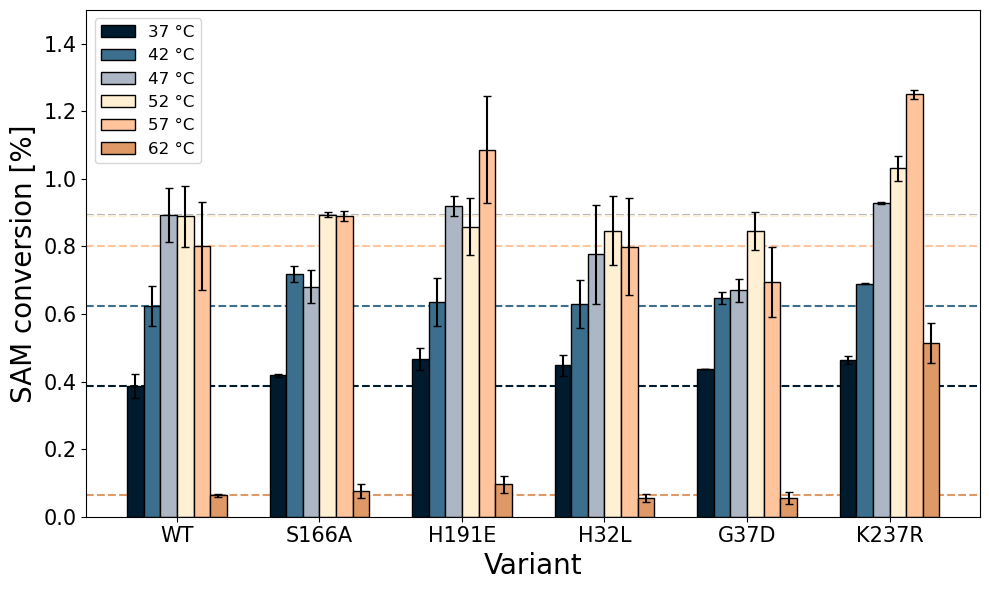

In [80]:
# Grouped bar plot
proteins = plot_conv["Protein"].unique()
temps = plot_conv["Temp."].unique()
x = np.arange(len(proteins))  # X locations for variants
width = 0.7  # Bar width (adjust if more temps)

fig, ax = plt.subplots(figsize=(10, 6))

for i, t in enumerate(temps):
    subset = plot_conv[plot_conv["Temp."] == t]
    ax.bar(
        x + i * width/len(temps),
        subset["mean"],
        yerr=subset["std"],
        width=width/len(temps),
        label=f"{t} °C",
        edgecolor="black",
        linewidth=1.0,
        capsize=3,
        color=colors_temp[t],
        zorder=2
    )
# Labels and title
ax.set_xlabel("Variant",fontsize=20)
ax.set_ylabel("SAM conversion [%]",fontsize=20)
ax.set_xticks(x + width/2 - width/(2*len(temps)))
ax.set_xticklabels(proteins, rotation=0, ha="center")
ax.legend(fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=15)

# Add horizontal line at WT values
for i,row in plot_conv[plot_conv["Protein"] == "WT"].iterrows():
    wt_value = row['mean']
    t = row['Temp.']
    ax.axhline(y=wt_value, linestyle="--",color=colors_temp[t],zorder=1)

ax.set_ylim(0, 1.5)

plt.tight_layout()
plt.show()

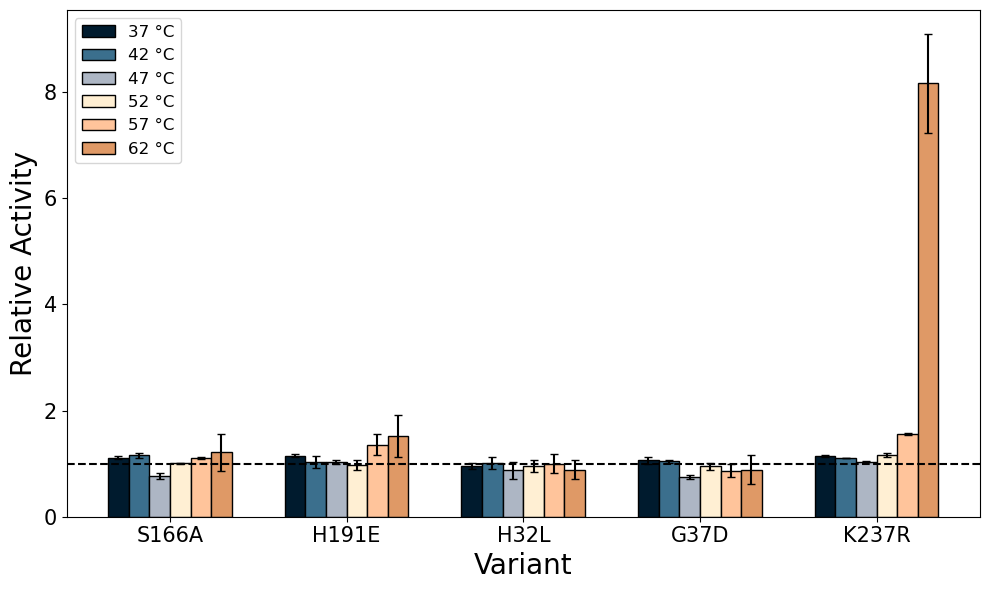

In [81]:
# Grouped bar plot
proteins = plot_rel["Protein"].unique()
temps = plot_rel["Temp."].unique()
x = np.arange(len(proteins))  # X locations for variants
width = 0.7  # Bar width (adjust if more temps)

fig, ax = plt.subplots(figsize=(10, 6))

for i, t in enumerate(temps):
    subset = plot_rel[plot_rel["Temp."] == t]
    ax.bar(
        x + i * width/len(temps),
        subset["mean"],
        yerr=subset["std"],
        width=width/len(temps),
        label=f"{t} °C",
        edgecolor="black",
        linewidth=1.0,
        capsize=3,
        color=colors_temp[t],
    )

# Add horizontal line at y=1
ax.axhline(y=1, color="black", linestyle="--")

# Labels
ax.set_xlabel("Variant",fontsize=20)
ax.set_ylabel("Relative Activity",fontsize=20)
ax.set_xticks(x + width/2 - width/(2*len(temps)))
ax.set_xticklabels(proteins, rotation=0, ha="center")
ax.legend(fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()

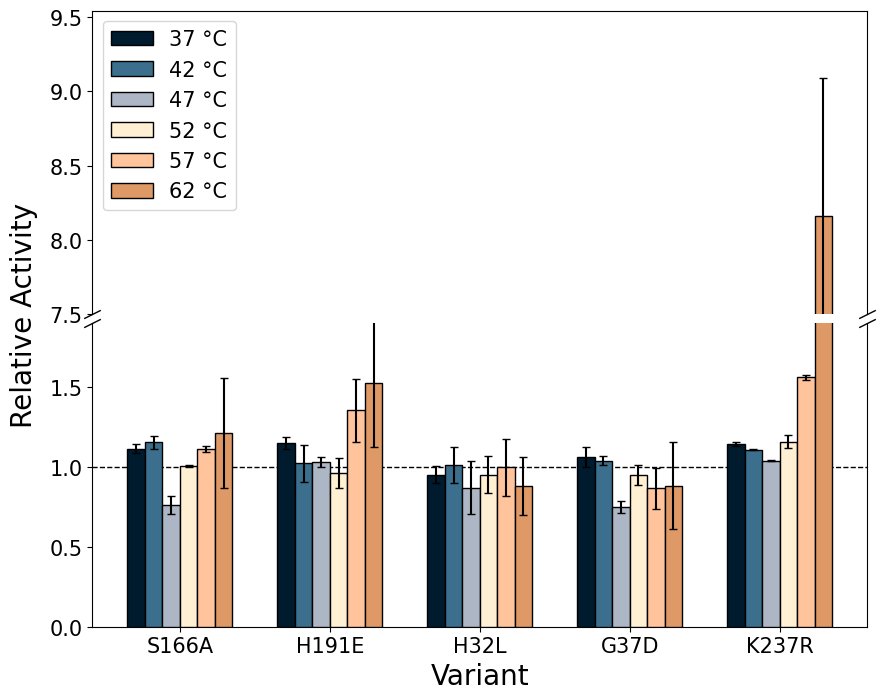

In [82]:
proteins = plot_rel["Protein"].unique()
temps     = plot_rel["Temp."].unique()
x = np.arange(len(proteins))
width = 0.70

# pick the cut ranges
bottom_ylim = (0.0, 1.9)  # most bars
y_max = float((plot_rel["mean"] + plot_rel["std"]).max())
top_ylim    = (7.5, max(8.6, y_max * 1.05))  # outlier region

# helper to draw grouped bars on a given axis
def draw_grouped(ax):
    for i, t in enumerate(temps):
        sub = plot_rel[plot_rel["Temp."] == t]
        ax.bar(
            x + i * width/len(temps),
            sub["mean"],
            yerr=sub["std"],
            width=width/len(temps),
            label=f"{t} °C",
            edgecolor="black",
            linewidth=1.0,
            capsize=3,
            color=colors_temp[t],
            zorder=3
        )

# ---- template-style broken axis ----
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
fig.subplots_adjust(hspace=0.03)  # space between axes

# plot same bars on both axes
draw_grouped(ax1)
draw_grouped(ax2)

# zoom / limits (top = outliers, bottom = bulk)
ax1.set_ylim(*top_ylim)
ax2.set_ylim(*bottom_ylim)

# reference line on bottom panel
ax2.axhline(1.0, color="black", linestyle="--", linewidth=1, zorder=2)

# hide the spines between the two axes, set ticks like in the template
ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(top=False, labeltop=False)
ax2.xaxis.tick_bottom()

# slanted break markers (exact template approach)
d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# labels / ticks / legend
ax2.set_xlabel("Variant", fontsize=20)
ax2.set_xticks(x + width/2 - width/(2*len(temps)))
ax2.set_xticklabels(proteins, rotation=0, ha="center")

ax1.set_yticks(np.arange(top_ylim[0], top_ylim[1], 0.5))

ax1.set_ylabel("Relative Activity", fontsize=20)
ax1.yaxis.set_label_coords(-0.07, 0)

ax1.tick_params(axis="y", labelsize=15)
ax2.tick_params(axis="both", which="major", labelsize=15)

# legend once (top-left above bottom axis)
ax1.legend(fontsize=15)


#plt.tight_layout()
plt.show()
